# Main results

The unit-level model with ethnicity-by-year fixed effects and the within-pair regression are the same estimator, so their coefficients have to match.

**Expected**

| specification | coefficient |
|---|---|
| unit and year FE | -0.2163 |
| ethnicity-by-year FE | -0.2096 |
| within-pair gap | -0.2096 |
| within-pair, year FE | -0.1656 |
| plus common trend | -0.0703 |
| plus group trends | -0.0424 |

In [1]:
import sys
sys.path.append("../src")

import pandas as pd

import config
import estimation

import figures
figures.setup()

Open Sans not found, falling back to DejaVu Sans


In [2]:
panel_df = pd.read_csv(config.WORK / 'panel_narrow.csv')
pair = pd.read_csv(config.WORK / 'pair_panel.csv')
specs = estimation.main_specifications(panel_df, pair)
specs.round(4)

,spec,coef,se,p,n
0,unit and year FE,-0.2163,0.1541,0.1604,726
1,ethnicity-by-year FE,-0.2096,0.1911,0.2728,726
2,within-pair gap,-0.2096,0.1350,0.1206,363
3,"within-pair gap, year FE",-0.1656,0.2938,0.5729,363
4,plus common linear trend,-0.0703,0.2156,0.7443,363
5,plus group-specific trends,-0.0424,0.2433,0.8618,363


In [3]:
a = specs.loc[specs['spec'] == 'ethnicity-by-year FE', 'coef'].iloc[0]
b = specs.loc[specs['spec'] == 'within-pair gap', 'coef'].iloc[0]
diff = abs(a - b)
print(f"difference between the two identical specifications: {diff:.3e}")
assert diff < 1e-4, f"specifications disagree by {diff:.4f}"

difference between the two identical specifications: 1.976e-14


In [4]:
estimation.cohort_effects(pair).round(4)

,cohort,coef,se,p,groups
0,1993,0.2820,0.5159,0.5847,2
1,1996,-0.1290,0.1075,0.2298,3
2,1998,-0.2619,0.2320,0.2590,5
3,2003,-0.2804,NaN,NaN,1


{'F': 0.5840302775960984, 'p': 0.6814626672313044, 'restrictions': 4}
saved event_study.pdf and event_study.png


,rel_year,coef,lo,hi,groups
0,-5,0.2451,-0.4779,0.9680,6
1,-4,-0.4006,-1.5661,0.7650,9
2,-3,0.1276,-0.4977,0.7528,9
3,-2,-0.0021,-0.6660,0.6619,9
4,-1,0.0000,0.0000,0.0000,11
5,0,-0.0457,-0.7742,0.6828,11
6,1,-0.0653,-0.7852,0.6546,11
7,2,-0.0595,-0.9830,0.8640,11
8,3,0.0413,-0.6178,0.7004,11
9,4,-0.0635,-0.7264,0.5993,11


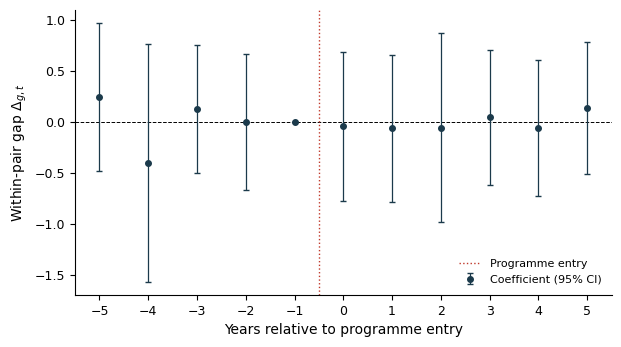

In [5]:
coefs, model, terms = estimation.event_study(pair)
print(estimation.pretrend_test(model, terms))
figures.event_study(coefs)
coefs.round(4)

saved sample_map.pdf and sample_map.png


(<Figure size 610x518.5 with 1 Axes>, <Axes: >)

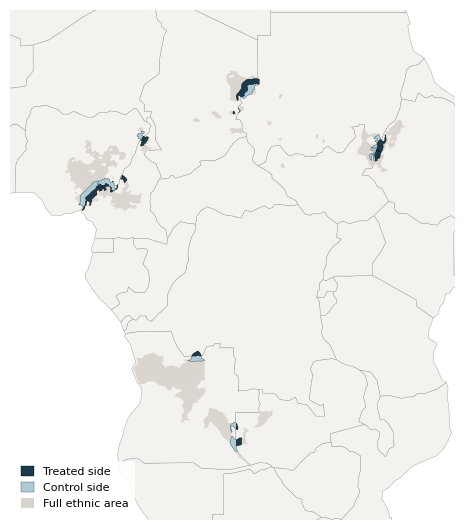

In [6]:
import geopandas as gpd

buffers = gpd.read_file(config.WORK / "buffers.gpkg")
sides = pair[["G1ID", "country_treated"]].drop_duplicates()
buffers = buffers.merge(sides, on="G1ID", how="inner")
buffers["treated"] = (buffers["FIPS_CNTRY"] == buffers["country_treated"]).astype(int)

world = gpd.read_file(config.COUNTRIES_110M)
africa = world[world["CONTINENT"] == "Africa"]

greg = gpd.read_file(config.GREG_SHP)
areas = greg[greg["G1ID"].isin(pair["G1ID"].unique())]

figures.sample_map(buffers, africa, ethnic_areas=areas)

saved event_time_bins.pdf and event_time_bins.png


,bin,coef,lo,hi,p,groups,n
0,≤ −6,0.3212,0.0034,0.6390,0.0476,6,11
1,−5 to −3,-0.0066,-0.3529,0.3396,0.9700,9,24
2,−2 to −1,0.0000,0.0000,0.0000,NaN,11,20
3,0 to 2,-0.0807,-0.5462,0.3848,0.7340,11,33
4,3 to 5,0.0142,-0.3457,0.3740,0.9385,11,33
5,6 to 10,-0.1156,-0.5247,0.2935,0.5796,11,55
6,11 to 15,-0.1911,-0.6619,0.2798,0.4264,11,55
7,> 15,-0.2227,-0.8000,0.3547,0.4497,11,132


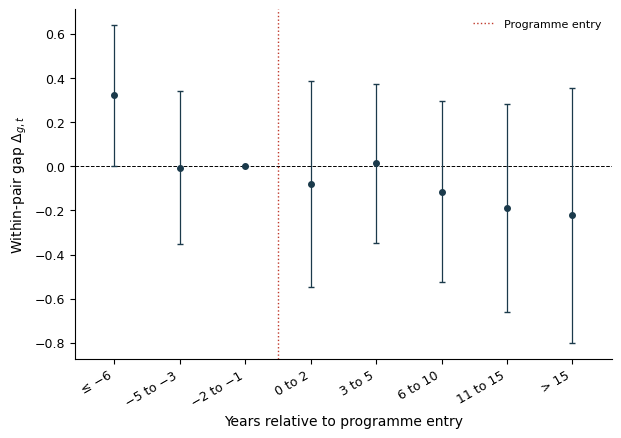

In [7]:
bins, bins_model = estimation.event_time_bins(pair)
figures.event_time_bins(bins)
bins.round(4)

In [8]:
estimation.cohort_effects(pair).to_csv(config.OUT / "cohort_effects.csv", index=False)
bins.to_csv(config.OUT / "event_time_bins.csv", index=False)
specs.to_csv(config.OUT / "main_specifications.csv", index=False)
coefs.to_csv(config.OUT / "event_study.csv", index=False)
print("saved")

saved


In [9]:
cs, cs_agg = estimation.callaway_santanna(panel_df)
print(f"aggregated ATT: {cs_agg:.4f}")
cs.round(4)

aggregated ATT: -0.1074


,cohort,att,se,n_treated
0,1993,0.8857,0.4780,2
1,1996,-0.8641,0.2332,3
2,1998,-0.0829,0.2340,5
3,2003,0.0540,0.2909,1


In [10]:
import panelbuild as panel_mod

lights_wide = pd.read_csv(config.WORK / "ntl_by_unit_year_wide.csv")
skeleton = pd.read_csv(config.WORK / "unit_year_treatment.csv")

panel_wide = panel_mod.build(lights_wide, skeleton, definition="narrow", label="wide")
pair_wide = panel_mod.pair_difference(panel_wide)

print()
for label, d in [("primary group only", pair), ("plus secondary polygons", pair_wide)]:
    m = estimation.cluster_fit(d, estimation.MAIN)
    print(f"{label:24s} beta = {m.params['post']:+.4f}  se = {m.bse['post']:.4f}  "
          f"groups = {d['G1ID'].nunique()}  n = {int(m.nobs)}")

[wide] treated from the first year on, dropped: [1179]
[wide] 11 groups, 22 units, 726 rows (balanced would be 726)
pair panel: 363 group-years, 11 groups

primary group only       beta = -0.2096  se = 0.1350  groups = 11  n = 363
plus secondary polygons  beta = -0.1363  se = 0.1146  groups = 11  n = 363


In [11]:
obs = float(estimation.cluster_fit(pair_wide, estimation.MAIN).params["post"])
boot = estimation.bootstrap(pair_wide)
print(estimation.describe_draws(boot, obs, "wide, cluster bootstrap"))

ar = pd.read_csv(config.WORK / "buffer_areas_wide.csv")
ratio = ar.groupby("G1ID")["area_km2"].agg(lambda s: s.max() / s.min()).round(3)
print()
print(ratio.sort_values(ascending=False).to_string())

{'spec': 'wide, cluster bootstrap', 'coef': -0.13627837682186517, 'se': 0.10837758792045728, 'lo': -0.32683443250380856, 'hi': 0.08978371464003816, 'p': 0.21621621621621623, 'null_distribution': False, 'draws': 999}

G1ID
1179    19.098
1095     6.972
224      5.388
574      4.128
503      3.284
124      2.246
1243     1.960
1192     1.936
321      1.931
173      1.713
1101     1.587
685      1.330


In [12]:
rows = []
for gid in sorted(pair["G1ID"].unique()):
    d = pair[pair["G1ID"] != gid]
    m = estimation.cluster_fit(d, estimation.MAIN)
    rows.append({"dropped": gid, "coef": round(float(m.params["post"]), 4),
                 "se": round(float(m.bse["post"]), 4),
                 "groups": d["G1ID"].nunique()})
loo = pd.DataFrame(rows).sort_values("coef")
print(loo.to_string(index=False))

 dropped    coef     se  groups
     685 -0.2796 0.1277      10
    1101 -0.2715 0.1333      10
     173 -0.2358 0.1353      10
    1243 -0.2296 0.1451      10
     321 -0.2243 0.1461      10
     574 -0.2053 0.1388      10
     124 -0.1956 0.1621      10
    1192 -0.1956 0.1470      10
    1095 -0.1711 0.1474      10
     224 -0.1582 0.1426      10
     503 -0.1350 0.1296      10


In [13]:
m = estimation.cluster_fit(pair, "gap ~ post:C(G1ID) + C(G1ID)")
rows = []
for t in [t for t in m.params.index if t.startswith("post:")]:
    gid = int(t.split("[")[-1].rstrip("]").lstrip("T."))
    rows.append({"G1ID": gid, "coef": round(float(m.params[t]), 4)})
byg = (pd.DataFrame(rows)
       .merge(pair[["G1ID", "name", "country_pair", "cohort"]].drop_duplicates(), on="G1ID")
       .sort_values("coef"))
print(byg.to_string(index=False))

 G1ID    coef                                 name country_pair  cohort
  503 -0.8088                      Jukun and Idoma        CM/NI    1998
  224 -0.6226                                 Bute        CM/NI    1998
 1095 -0.5190                                Tikar        CM/NI    1998
  574 -0.4001                                 Koma        ET/SU    1993
 1192 -0.3725 Waluchazi (incl. Waluimbe, Wambundu)        ZA/AO    1996
  124 -0.2804                             Bambundu        CG/AO    2003
  321 -0.0381                                 Dago        CD/SU    1996
 1243  0.0235                               Zagawa        CD/SU    1996
 1101  0.2880      Tiv (incl. Ekoi, Boki, Jarawas)        CM/NI    1998
  685  0.3531       Mandara (incl. Matakam, Gidar)        CM/NI    1998
  173  0.9640                                Berta        ET/SU    1993


In [14]:
w = pair.groupby("G1ID")["post"].apply(lambda s: ((s - s.mean()) ** 2).sum())
byg = byg.set_index("G1ID")
byg["weight"] = (w / w.sum()).round(4)
print(f"simple mean:   {byg['coef'].mean():+.4f}")
print(f"weighted mean: {(byg['coef'] * byg['weight']).sum():+.4f}")
print(byg[["name", "cohort", "coef", "weight"]].to_string())

simple mean:   -0.1284
weighted mean: -0.2096
                                      name  cohort    coef  weight
G1ID                                                              
503                        Jukun and Idoma    1998 -0.8088  0.1107
224                                   Bute    1998 -0.6226  0.1107
1095                                 Tikar    1998 -0.5190  0.1107
574                                   Koma    1993 -0.4001  0.0219
1192  Waluchazi (incl. Waluimbe, Wambundu)    1996 -0.3725  0.0792
124                               Bambundu    2003 -0.2804  0.1653
321                                   Dago    1996 -0.0381  0.0792
1243                                Zagawa    1996  0.0235  0.0792
1101       Tiv (incl. Ekoi, Boki, Jarawas)    1998  0.2880  0.1107
685         Mandara (incl. Matakam, Gidar)    1998  0.3531  0.1107
173                                  Berta    1993  0.9640  0.0219


In [15]:
m = estimation.cluster_fit(pair_wide, estimation.MAIN)
print(f"{m.params['post']:+.4f}  se {m.bse['post']:.4f}  p {m.pvalues['post']:.4f}")

-0.1363  se 0.1146  p 0.2344
